In [1]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator          

from sklearn.base import BaseEstimator
from sklearn.utils.validation import check_X_y

# Các mô hình cơ sở
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Thư viện DES
from deslib.des.knora_e import KNORAE
import shap

In [2]:
# 1. Đọc dữ liệu đã qua tiền xử lý (đã điền khuyết và chuẩn hóa)
train_df = pd.read_csv('../data/processed/train_processed.csv')
test_df = pd.read_csv('../data/processed/test_processed.csv')

X_train_full = train_df.drop(columns=['lung_cancer_risk'])
y_train_full = train_df['lung_cancer_risk']

X_test = test_df.drop(columns=['lung_cancer_risk'])
y_test = test_df['lung_cancer_risk']

print(f"Kích thước tập Train ban đầu: {X_train_full.shape}")

Kích thước tập Train ban đầu: (4000, 29)


In [3]:
# 2. Áp dụng RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_full, y_train_full)

print(f"Kích thước tập Train sau Undersampling: {X_train_rus.shape}")

# 3. Tách tập Train sau Undersampling thành 2 phần:
# - Phần 1 (X_train_base): Để huấn luyện 4 mô hình cơ sở
# - Phần 2 (X_dsel): Tập Validation để Cân chỉnh (Calibration) và huấn luyện DES
X_train_base, X_dsel, y_train_base, y_dsel = train_test_split(
    X_train_rus, y_train_rus, test_size=0.3, random_state=42, stratify=y_train_rus
)

Kích thước tập Train sau Undersampling: (1990, 29)


In [4]:
print("Đang huấn luyện và cân chỉnh 4 mô hình cơ sở...")

# Định nghĩa 4 mô hình (SVM cần bật probability=True)
models = {
    'LR': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LGBM': LGBMClassifier(random_state=42, verbose=-1)
}

calibrated_models = []
trained_base_models = {} # Lưu lại để lát dùng SHAP giải thích

for name, model in models.items():
    # 1. Huấn luyện mô hình cơ sở
    model.fit(X_train_base, y_train_base)
    trained_base_models[name] = model
    
    # 2. Cân chỉnh (Calibration) bằng method 'sigmoid'
    # Bỏ tham số cv='prefit' đi và bọc model bằng FrozenEstimator
    calibrated_clf = CalibratedClassifierCV(
        estimator=FrozenEstimator(model), 
        method='sigmoid'
    )
    calibrated_clf.fit(X_dsel, y_dsel)
    
    calibrated_models.append(calibrated_clf)
    print(f" -> Đã hoàn tất: {name}")

Đang huấn luyện và cân chỉnh 4 mô hình cơ sở...
 -> Đã hoàn tất: LR
 -> Đã hoàn tất: SVM
 -> Đã hoàn tất: XGBoost
 -> Đã hoàn tất: LGBM


In [5]:
# --- ĐÁNH GIÁ TỪNG MÔ HÌNH ĐƠN LẺ ---
print("--- ĐIỂM SỐ CỦA TỪNG MÔ HÌNH TRƯỚC KHI GỘP (DES) ---")

# Vòng lặp duyệt qua 4 mô hình đã được huấn luyện và cân chỉnh
for name, model in zip(models.keys(), calibrated_models):
    # Dự đoán
    y_pred_single = model.predict(X_test)
    y_proba_single = model.predict_proba(X_test)[:, 1]
    
    # Tính ROC-AUC
    auc_single = roc_auc_score(y_test, y_proba_single)
    
    print(f"\n=========================================")
    print(f"BÁO CÁO CỦA MÔ HÌNH: {name}")
    print(f"Điểm ROC-AUC: {auc_single:.4f}")
    print("-----------------------------------------")
    print(classification_report(y_test, y_pred_single))

--- ĐIỂM SỐ CỦA TỪNG MÔ HÌNH TRƯỚC KHI GỘP (DES) ---

BÁO CÁO CỦA MÔ HÌNH: LR
Điểm ROC-AUC: 0.9995
-----------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       751
           1       0.96      0.99      0.98       249

    accuracy                           0.99      1000
   macro avg       0.98      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


BÁO CÁO CỦA MÔ HÌNH: SVM
Điểm ROC-AUC: 0.9981
-----------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       751
           1       0.93      0.97      0.95       249

    accuracy                           0.97      1000
   macro avg       0.96      0.97      0.97      1000
weighted avg       0.98      0.97      0.98      1000


BÁO CÁO CỦA MÔ HÌNH: XGBoost
Điểm ROC-AUC: 0.9970
-----------------------------------------
              precision

In [6]:
print("Đang khởi tạo mô hình Dynamic Ensemble Selection (DES)...")

# --- BẮT ĐẦU ĐOẠN VÁ LỖI (MONKEY-PATCH) ---
# Bổ sung lại hàm _validate_data đã bị xóa trong scikit-learn 1.6+ để cứu thư viện deslib
if not hasattr(BaseEstimator, '_validate_data'):
    def _validate_data_patch(self, X, y=None, reset=True, validate_separately=False, **check_params):
        return check_X_y(X, y, **check_params)
    BaseEstimator._validate_data = _validate_data_patch
# --- KẾT THÚC ĐOẠN VÁ LỖI ---

# Khởi tạo mô hình DES với danh sách 4 mô hình đã cân chỉnh
des_model = KNORAE(pool_classifiers=calibrated_models, random_state=42)

# Huấn luyện DES trên tập DSEL để nó học cách phân tài
des_model.fit(X_dsel, y_dsel)

# Dự đoán trên tập Test
y_pred = des_model.predict(X_test)
y_pred_proba = des_model.predict_proba(X_test)[:, 1]

print("Đã hoàn tất dự đoán bằng DES!")

Đang khởi tạo mô hình Dynamic Ensemble Selection (DES)...
Đã hoàn tất dự đoán bằng DES!


In [7]:
# Tạo một list rỗng để hứng dữ liệu điểm số
evaluation_results = []

# 1. Thu thập điểm số của 4 mô hình cơ sở
# Nhắc lại: models.keys() chứa tên ['LR', 'SVM', 'XGBoost', 'LGBM']
for name, model in zip(models.keys(), calibrated_models):
    y_pred_single = model.predict(X_test)
    y_proba_single = model.predict_proba(X_test)[:, 1]
    
    evaluation_results.append({
        'Tên Mô Hình': name,
        'ROC-AUC': roc_auc_score(y_test, y_proba_single),
        'Độ chính xác (Accuracy)': accuracy_score(y_test, y_pred_single),
        'Độ bao phủ - Recall (Ung thư)': recall_score(y_test, y_pred_single),
        'F1-Score (Ung thư)': f1_score(y_test, y_pred_single)
    })

# 2. Thu thập điểm số của mô hình gộp DES
y_pred_des = des_model.predict(X_test)
y_proba_des = des_model.predict_proba(X_test)[:, 1]

evaluation_results.append({
    'Tên Mô Hình': '🌟 DES (Mô hình Gộp)',
    'ROC-AUC': roc_auc_score(y_test, y_proba_des),
    'Độ chính xác (Accuracy)': accuracy_score(y_test, y_pred_des),
    'Độ bao phủ - Recall (Ung thư)': recall_score(y_test, y_pred_des),
    'F1-Score (Ung thư)': f1_score(y_test, y_pred_des)
})

# 3. Xuất ra bảng DataFrame cho đẹp và dễ nhìn
# Sắp xếp bảng theo thứ hạng điểm ROC-AUC từ cao xuống thấp
df_compare = pd.DataFrame(evaluation_results)
df_compare = df_compare.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("--- BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH ---")
# Hàm display() của Jupyter Notebook sẽ in ra bảng có format hàng cột rất đẹp
display(df_compare)

--- BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH ---


,Tên Mô Hình,ROC-AUC,Độ chính xác (Accuracy),Độ bao phủ - Recall (Ung thư),F1-Score (Ung thư)
0,LR,0.999524,0.989,0.991968,0.978218
1,SVM,0.998150,0.975,0.967871,0.950690
2,XGBoost,0.997021,0.972,0.959839,0.944664
3,LGBM,0.996642,0.970,0.963855,0.941176
4,🌟 DES (Mô hình Gộp),0.988556,0.982,0.963855,0.963855


--- BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       751
           1       0.96      0.96      0.96       249

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

Điểm ROC-AUC của mô hình DES: 0.9886



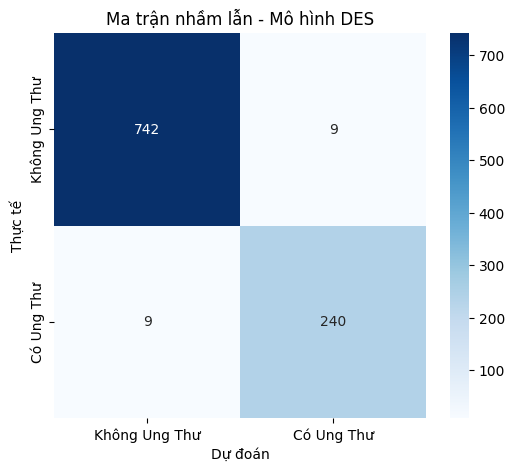

In [8]:
print("--- BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Điểm ROC-AUC của mô hình DES: {roc_auc:.4f}\n")

# Vẽ Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Không Ung Thư', 'Có Ung Thư'], 
            yticklabels=['Không Ung Thư', 'Có Ung Thư'])
plt.title('Ma trận nhầm lẫn - Mô hình DES')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

Đang trích xuất giá trị SHAP để giải thích...


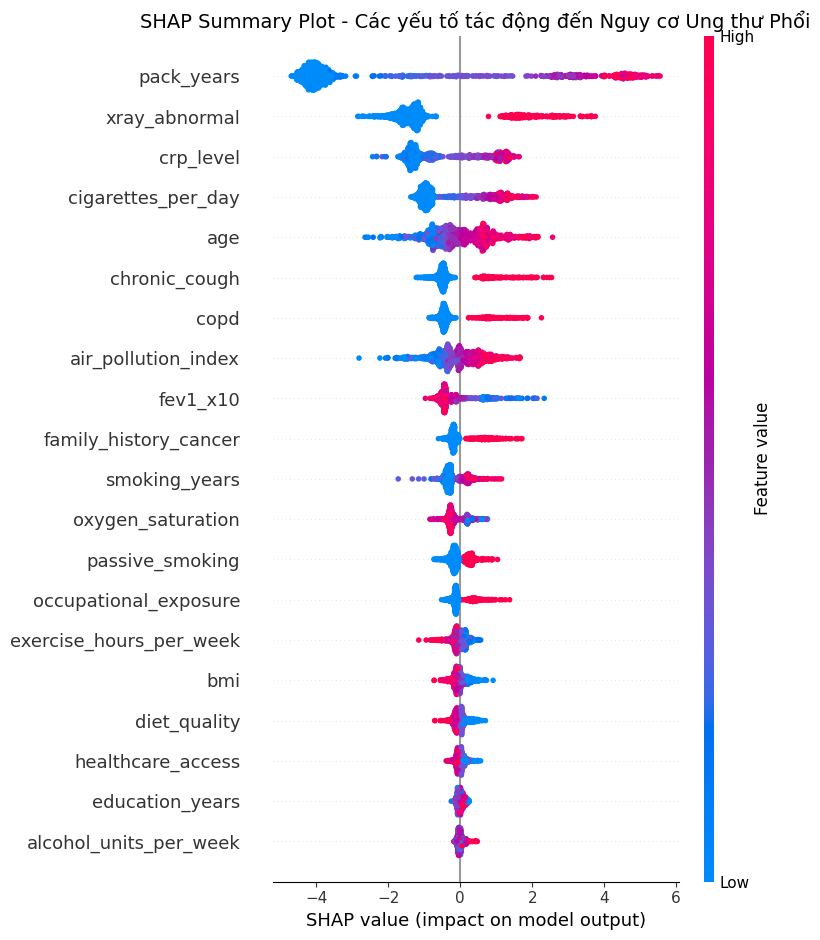

In [9]:
print("Đang trích xuất giá trị SHAP để giải thích...")

# Dùng mô hình LightGBM (mô hình cây mạnh nhất trong 4 mô hình cơ sở) để phân tích SHAP
lgbm_model = trained_base_models['LGBM']

# Khởi tạo TreeExplainer
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)

# Vẽ biểu đồ Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot - Các yếu tố tác động đến Nguy cơ Ung thư Phổi", fontsize=14)

# Lưu ý: Với LightGBM phiên bản mới, shap_values có thể trả về mảng 2D cho class 1 hoặc list 2 mảng.
# Thường ta truyền thẳng shap_values nếu là phân loại nhị phân (phụ thuộc vào version SHAP/LGBM).
try:
    shap.summary_plot(shap_values[1], X_test) # Dành cho list [class_0, class_1]
except:
    shap.summary_plot(shap_values, X_test)    # Dành cho mảng trực tiếp

In [10]:
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix

# 1. Lấy kết quả ma trận nhầm lẫn
# cm[0,0]: Thực tế KHÔNG -> Đoán KHÔNG (Đúng)
# cm[0,1]: Thực tế KHÔNG -> Đoán CÓ (Sai)
# cm[1,0]: Thực tế CÓ -> Đoán KHÔNG (Sai)
# cm[1,1]: Thực tế CÓ -> Đoán CÓ (Đúng)
cm = confusion_matrix(y_test, y_pred)

# 2. Cấu hình các Nút (Nodes)
# 0, 1 là nhánh Thực tế. 2, 3 là nhánh Dự đoán.
labels = [
    "Thực tế: KHÔNG Ung thư", # Node 0
    "Thực tế: CÓ Ung thư",    # Node 1
    "Dự đoán: KHÔNG Ung thư", # Node 2
    "Dự đoán: CÓ Ung thư"     # Node 3
]

# Màu sắc cho các Nút (Xanh lá = Không, Đỏ = Có)
node_colors = ["#2ecc71", "#e74c3c", "#2ecc71", "#e74c3c"]

# 3. Cấu hình Dòng chảy (Links)
sources = [0, 0, 1, 1] # Điểm xuất phát
targets = [2, 3, 2, 3] # Điểm đến
values = [cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]] # Số lượng (Độ rộng của dòng chảy)

# Màu của dòng chảy (Xanh nhạt cho dự đoán ĐÚNG, Đỏ nhạt cho dự đoán SAI)
link_colors = [
    "rgba(46, 204, 113, 0.4)",  # Thực tế KHÔNG -> Đoán KHÔNG (Đúng)
    "rgba(231, 76, 60, 0.5)",   # Thực tế KHÔNG -> Đoán CÓ (Sai - Báo động nhầm)
    "rgba(231, 76, 60, 0.5)",   # Thực tế CÓ -> Đoán KHÔNG (Sai - Bỏ lọt bệnh)
    "rgba(46, 204, 113, 0.4)"   # Thực tế CÓ -> Đoán CÓ (Đúng)
]

# 4. Vẽ biểu đồ Sankey
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 20,
      thickness = 30,
      line = dict(color = "black", width = 0.5),
      label = labels,
      color = node_colors
    ),
    link = dict(
      source = sources,
      target = targets,
      value = values,
      color = link_colors
    )
)])

# 5. Tùy chỉnh Layout
fig.update_layout(
    title_text="BIỂU ĐỒ SANKEY: PHÂN LUỒNG KẾT QUẢ CHẨN ĐOÁN (THỰC TẾ VS DỰ ĐOÁN)",
    font_size=13,
    height=500,
    plot_bgcolor='white'
)

fig.show()

In [12]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Ở file này, chúng ta chỉ có mô hình DES nên chỉ lưu des_model
joblib.dump(des_model, '../models/des_model.pkl')
print("Đã xuất file mô hình des_model.pkl thành công!")

Đã xuất file mô hình des_model.pkl thành công!
